### Read model and emulator predictions for CosmoGridV1 cosmology, and compare it with the measured signal

In [ ]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

In [2]:
def getarray(fitsfile):
    # Load the FITS file
    hdul1 = fits.open(fitsfile)

    x = []
    for i in range(80):
        x.append(hdul1[1].data[i][6])
    y = np.array(x)
    
    return(y)

In [3]:
#COSMOGRID MODEL AND EMULATOR
theory = getarray("../data/dv/sim_map3-NLA-cosmoCosmoG.fits")
emulator = getarray("../data/dv/sim_map3-NLA-emu-cosmoCosmoG.fits")

theory_sections = np.split(theory,20)
emulator_sections = np.split(emulator,20)

In [4]:
#NOW GET THE MEASURED DATA VECTOR AND COVARIANCE

datavector_0 = np.load("../data/nz/final_400sims/Apr19NOISY_scalecut_DATAVECTOR.npy")
cov = np.load("../data/nz/final_400sims/Apr19NOISY_scalecut_COVARIANCE_400SIMS.npy")

In [5]:
#NOW GET THE NOISELESS DATA VECTOR AND COVARIANCE

datavector_1 = np.load("/Users/gchgomes/3pcf_integrator/data/nz/final_noiseless/May16NOISELESS_DATAVECTOR.npy")
cov1 = np.load("/Users/gchgomes/3pcf_integrator/data/nz/final_noiseless/May16NOISELESS_COVARIANCE_400SIMS.npy")

In [ ]:
#inv_cov = np.linalg.inv(cov)*(400-80-2)/(400-1)
#theodiff = theo - datavector_0
#chisq = np.matmul(theodiff,np.matmul(inv_cov, theodiff))
#print(chisq)

In [ ]:
#print(100*(datavector_0-2*theo_corr_at80)/datavector_0)

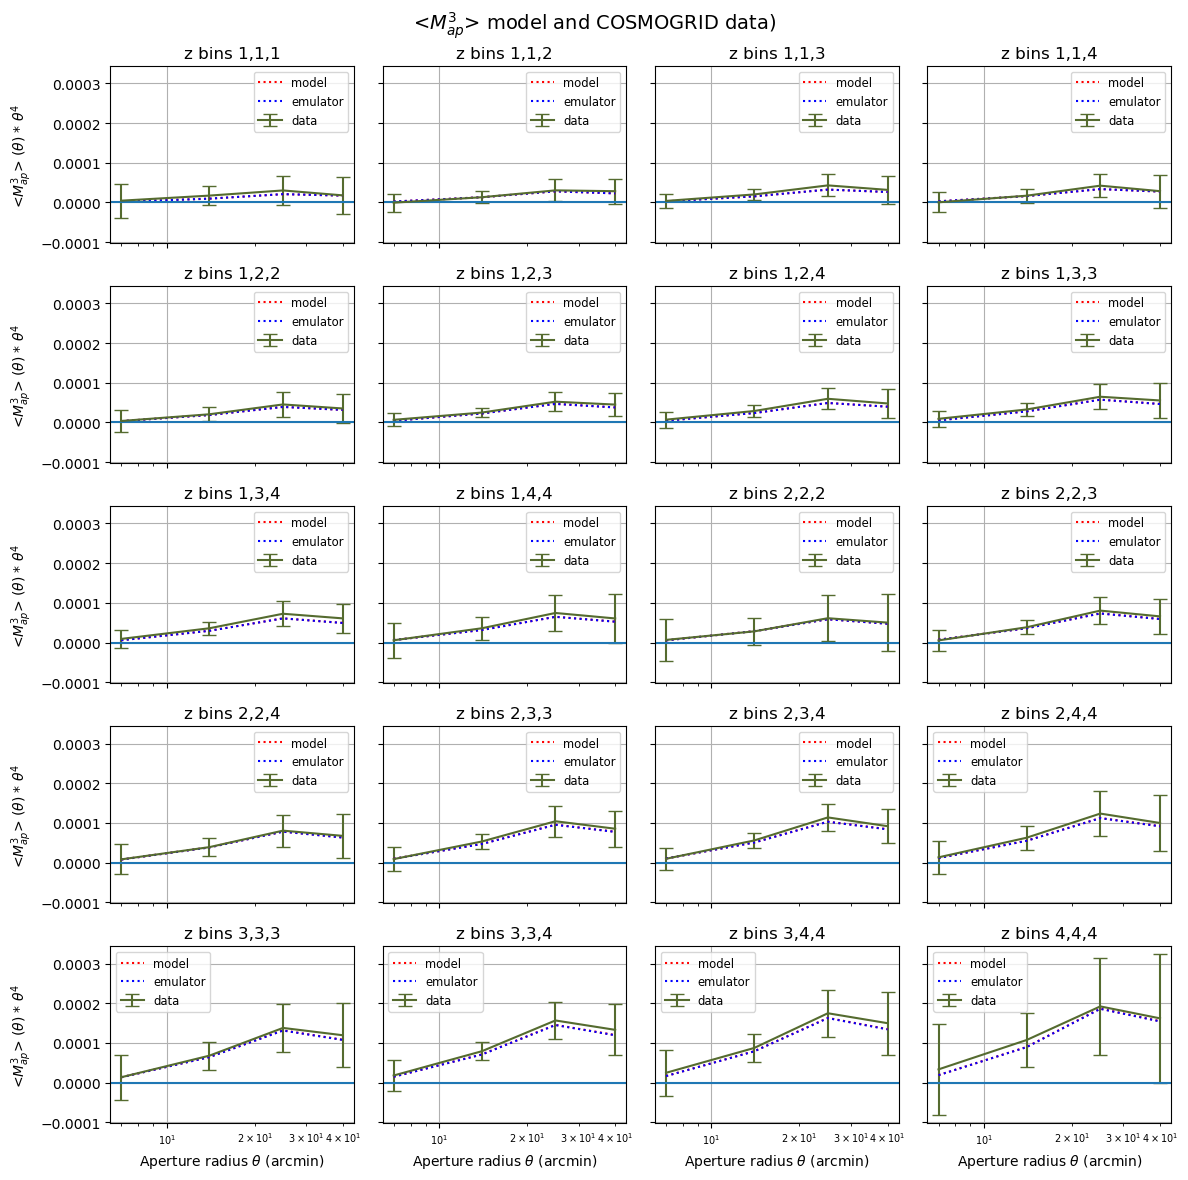

In [6]:
data_sections = np.split(datavector_0, 20)
errors = np.sqrt(np.diag(cov))

data_sections1 = np.split(datavector_1, 20)
errors1 = np.sqrt(np.diag(cov1))

indx = [[1,1,1],[1,1,2],[1,1,3],[1,1,4],[1,2,2],[1,2,3],[1,2,4],[1,3,3],[1,3,4],[1,4,4],[2,2,2],
        [2,2,3],[2,2,4],[2,3,3],[2,3,4],[2,4,4],[3,3,3],[3,3,4],[3,4,4],[4,4,4]]

fig, axs = plt.subplots(5, 4, figsize=(12, 12), sharey=True, sharex=True)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each subplot and plot the data
for i, ax in enumerate(axs):
    x_values = np.array([7,14,25,40])
    y_values = data_sections[i]
    y_values1 = data_sections1[i]
    ax.errorbar(x_values, x_values**4*y_values, yerr=x_values**4*errors[i*4:i*4+4], color='darkolivegreen', capsize=5, label='data')
    ax.plot(x_values, theory_sections[i]*x_values**4, color='r', ls=':',label='model')
    ax.plot(x_values, emulator_sections[i]*x_values**4, color='b', ls=':',label='emulator')
    ax.axhline(y=0)
    ax.set_title(f'z bins {indx[i][0]},{indx[i][1]},{indx[i][2]}')
    if i >= 16:
        ax.set_xlabel(r"Aperture radius $\theta$ (arcmin)")
    
    ax.tick_params(axis='x', which='both', labelsize=7) 
        
    # Set y labels only for the leftmost column of subplots
    if i % 4 == 0:
        ax.set_ylabel(r"<$M_{ap}^3$> ($\theta$) * $\theta^4$")
        
    #ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid()
    ax.legend(fontsize='small')

fig.suptitle(r"<$M_{ap}^3$> model and COSMOGRID data)", fontsize=14)
    
# Adjust layout to prevent overlap of subplots
plt.tight_layout()

# Show the plot
plt.show()

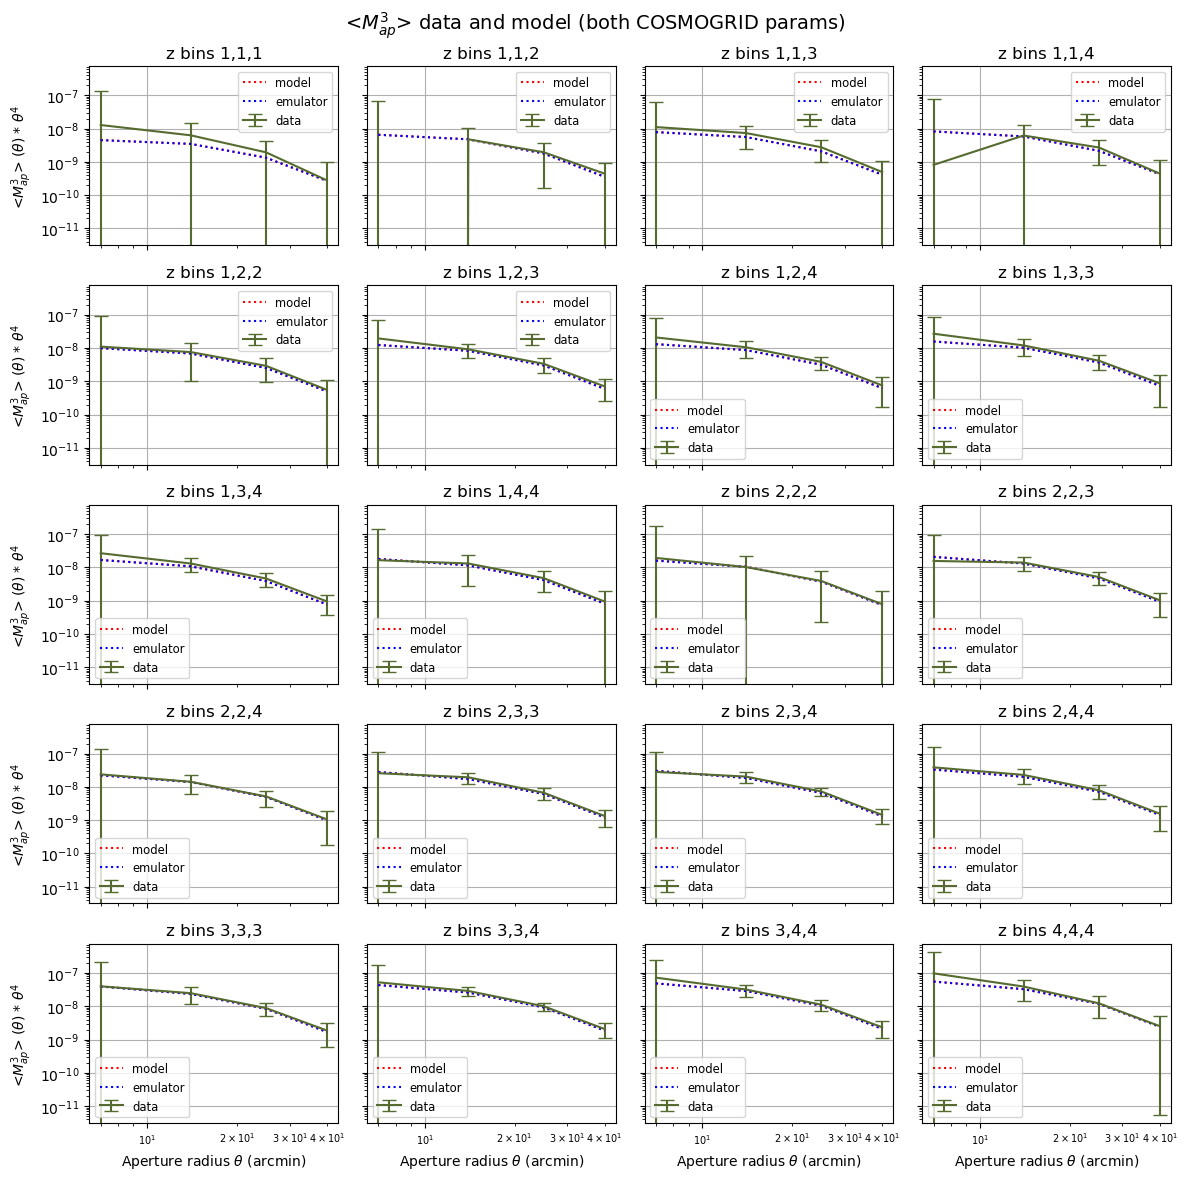

In [7]:
data_sections = np.split(datavector_0, 20)
errors = np.sqrt(np.diag(cov))

indx = [[1,1,1],[1,1,2],[1,1,3],[1,1,4],[1,2,2],[1,2,3],[1,2,4],[1,3,3],[1,3,4],[1,4,4],[2,2,2],
        [2,2,3],[2,2,4],[2,3,3],[2,3,4],[2,4,4],[3,3,3],[3,3,4],[3,4,4],[4,4,4]]

fig, axs = plt.subplots(5, 4, figsize=(12, 12), sharey=True, sharex=True)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each subplot and plot the data
for i, ax in enumerate(axs):
    x_values = np.array([7,14,25,40])
    y_values = data_sections[i]
    ax.errorbar(x_values, x_values*y_values, yerr=x_values*errors[i*4:i*4+4], color='darkolivegreen', capsize=5, label='data')
    ax.plot(x_values, theory_sections[i]*x_values, color='r', ls=':',label='model')
    ax.plot(x_values, emulator_sections[i]*x_values, color='b', ls=':',label='emulator')
    ax.set_title(f'z bins {indx[i][0]},{indx[i][1]},{indx[i][2]}')
    if i >= 16:
        ax.set_xlabel(r"Aperture radius $\theta$ (arcmin)")
    
    ax.tick_params(axis='x', which='both', labelsize=7) 
        
    # Set y labels only for the leftmost column of subplots
    if i % 4 == 0:
        ax.set_ylabel(r"<$M_{ap}^3$> ($\theta$) * $\theta^4$")
        
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid()
    ax.legend(fontsize='small')

fig.suptitle(r"<$M_{ap}^3$> data and model (both COSMOGRID params)", fontsize=14)
    
# Adjust layout to prevent overlap of subplots
plt.tight_layout()

# Show the plot
plt.show()

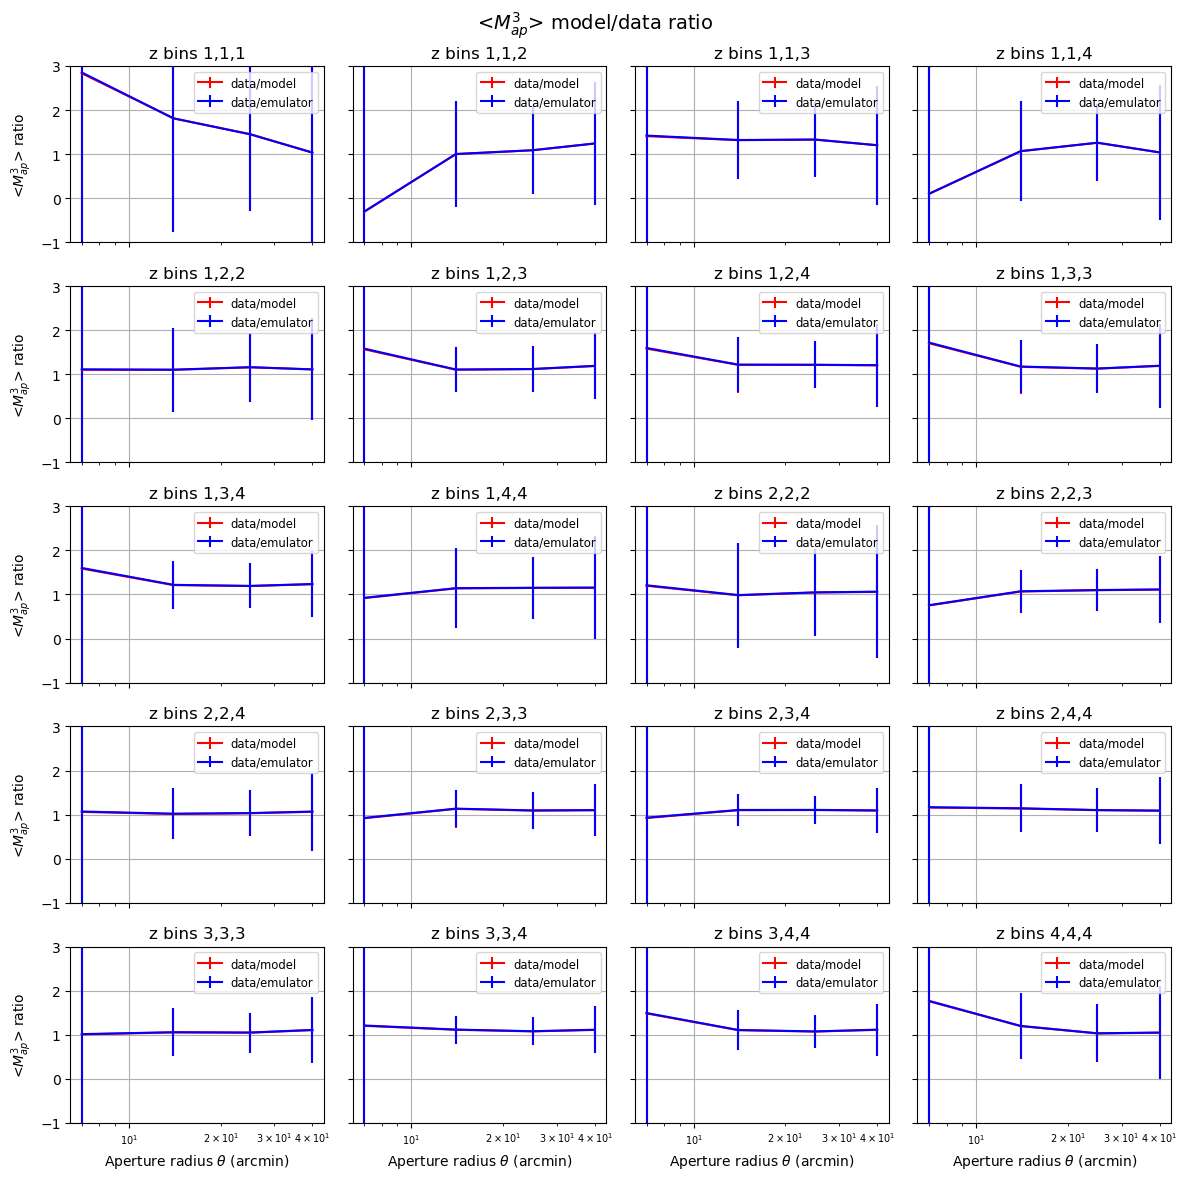

In [16]:
data_sections = np.split(datavector_0, 20)
errors = np.sqrt(np.diag(cov))

indx = [[1,1,1],[1,1,2],[1,1,3],[1,1,4],[1,2,2],[1,2,3],[1,2,4],[1,3,3],[1,3,4],[1,4,4],[2,2,2],
        [2,2,3],[2,2,4],[2,3,3],[2,3,4],[2,4,4],[3,3,3],[3,3,4],[3,4,4],[4,4,4]]

fig, axs = plt.subplots(5, 4, figsize=(12, 12), sharey=True, sharex=True)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each subplot and plot the data
for i, ax in enumerate(axs):
    x_values = np.array([7,14,25,40])
    y_values = data_sections[i]
    ax.errorbar(x_values, data_sections[i]/theory_sections[i], yerr=errors[i*4:i*4+4]/theory_sections[i], color='r', label='data/model')
    ax.errorbar(x_values, data_sections[i]/emulator_sections[i], yerr=errors[i*4:i*4+4]/emulator_sections[i], color='b', label='data/emulator')
    ax.set_title(f'z bins {indx[i][0]},{indx[i][1]},{indx[i][2]}')
    if i >= 16:
        ax.set_xlabel(r"Aperture radius $\theta$ (arcmin)")
    
    ax.tick_params(axis='x', which='both', labelsize=7) 
        
    # Set y labels only for the leftmost column of subplots
    if i % 4 == 0:
        ax.set_ylabel(r"<$M_{ap}^3$> ratio")
        
    ax.set_ylim(-1,3)
    #ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid()
    ax.legend(fontsize='small')

fig.suptitle(r"<$M_{ap}^3$> model/data ratio", fontsize=14)
    
# Adjust layout to prevent overlap of subplots
plt.tight_layout()

# Show the plot
plt.show()